In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


In [17]:

df = pd.read_csv("weatherHistory.csv")


df.head()


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [18]:
# Remove unnecessary columns
df = df[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Precip Type']]

# Drop missing values
df.dropna(inplace=True)

# Convert temperature C → F
df['temp_f'] = df['Temperature (C)'] * 9/5 + 32


df['Precip Type'] = df['Precip Type'].str.lower()



In [20]:
# Add weather condition flags
df['is_rain'] = df['Precip Type'].str.contains('rain', na=False).astype(int)
df['is_snow'] = df['Precip Type'].str.contains('snow', na=False).astype(int)

# Wind indicator (>20 km/h = windy)
df['is_windy'] = (df['Wind Speed (km/h)'] > 20).astype(int)




In [24]:
def get_clothing_label(row):
    temp = row['temp_f']
    rain = row['is_rain']
    snow = row['is_snow']
    wind = row['is_windy']


    if temp < 40:
        label = "Heavy Coat"
    elif temp < 60:
        label = "Jacket"
    elif temp < 75:
        label = "Long Sleeve"
    else:
        label = "T-shirt"

   
    if snow == 1:
        label = "Heavy Coat + Boots" 
    if rain == 1:
        label += " + Raincoat"
    if wind == 1:
        label += " + Windbreaker"

    return label

df['label'] = df.apply(get_clothing_label, axis=1)
print(df[['temp_f', 'is_rain', 'is_snow', 'is_windy', 'label']])



       temp_f  is_rain  is_snow  is_windy                   label
0       49.05        1        0         0       Jacket + Raincoat
1       48.84        1        0         0       Jacket + Raincoat
2       48.88        1        0         0       Jacket + Raincoat
3       46.92        1        0         0       Jacket + Raincoat
4       47.76        1        0         0       Jacket + Raincoat
...       ...      ...      ...       ...                     ...
96448   78.83        1        0         0      T-shirt + Raincoat
96449   76.25        1        0         0      T-shirt + Raincoat
96450   71.67        1        0         0  Long Sleeve + Raincoat
96451   70.74        1        0         0  Long Sleeve + Raincoat
96452   68.79        1        0         0  Long Sleeve + Raincoat

[95936 rows x 5 columns]


In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

x= df[['temp_f', 'Humidity', 'Wind Speed (km/h)', 'is_rain', 'is_snow', 'is_windy']]
y = df['label_encoded']


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [28]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [29]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1967
           1       1.00      1.00      1.00       175
           2       1.00      1.00      1.00      2302
           3       1.00      1.00      1.00       290
           4       1.00      1.00      1.00      6376
           5       1.00      1.00      1.00       991
           6       1.00      1.00      1.00      4381
           7       1.00      1.00      1.00       478
           8       1.00      1.00      1.00      2032
           9       1.00      1.00      1.00       196

    accuracy                           1.00     19188
   macro avg       1.00      1.00      1.00     19188
weighted avg       1.00      1.00      1.00     19188



In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm


array([[1967,    0,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0,  175,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0, 2302,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0,    0,  290,    0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0, 6376,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,  991,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0, 4381,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,  478,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0, 2032,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,  196]])

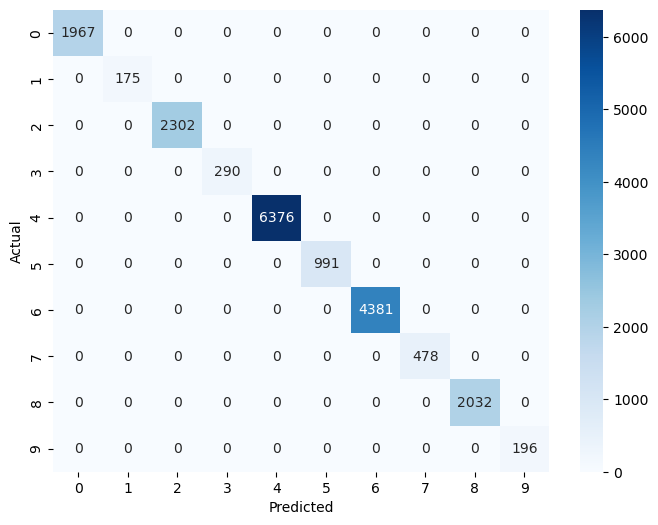

In [31]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [32]:
digital_closet = [
    {"name": "Black Puffer Coat", "category": "Heavy Coat"},
    {"name": "Blue Denim Jacket", "category": "Jacket"},
    {"name": "Beige Trench Coat", "category": "Jacket"},
    {"name": "Gray Hoodie", "category": "Long Sleeve"},
    {"name": "White T-shirt", "category": "T-shirt"},
    {"name": "Yellow Raincoat", "category": "Raincoat"},
    {"name": "Snow Boots", "category": "Boots"},
    {"name": "Blue Windbreaker", "category": "Windbreaker"}
]


In [33]:
def recommend_from_closet(predicted_label, closet):
    predicted_label = predicted_label.lower()
    matches = []

    for item in closet:
        cat = item["category"].lower()
        if cat in predicted_label:
            matches.append(item)

    return matches


In [34]:
sample_weather = X_test.iloc[0:1]
pred_encoded = model.predict(sample_weather)[0]
pred_label = le.inverse_transform([pred_encoded])[0]
pred_label


'Jacket + Raincoat'

In [35]:
matches = recommend_from_closet(pred_label, digital_closet)

print("Predicted Clothing Label:", pred_label)
print("\nMatching Closet Items:")
for item in matches:
    print("-", item["name"], "(", item["category"], ")")


Predicted Clothing Label: Jacket + Raincoat

Matching Closet Items:
- Blue Denim Jacket ( Jacket )
- Beige Trench Coat ( Jacket )
- Yellow Raincoat ( Raincoat )


In [36]:
def api_recommend(weather_input, closet_items):
    pred_encoded = model.predict(weather_input)[0]
    pred_label = le.inverse_transform([pred_encoded])[0]
    matches = recommend_from_closet(pred_label, closet_items)
    return {"prediction": pred_label, "recommendations": matches}

api_recommend(sample_weather, digital_closet)


{'prediction': 'Jacket + Raincoat',
 'recommendations': [{'name': 'Blue Denim Jacket', 'category': 'Jacket'},
  {'name': 'Beige Trench Coat', 'category': 'Jacket'},
  {'name': 'Yellow Raincoat', 'category': 'Raincoat'}]}